<a href="https://colab.research.google.com/github/GabrielMtzSoltero/MIEC/blob/main/MIEC_RegresionPolinomial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

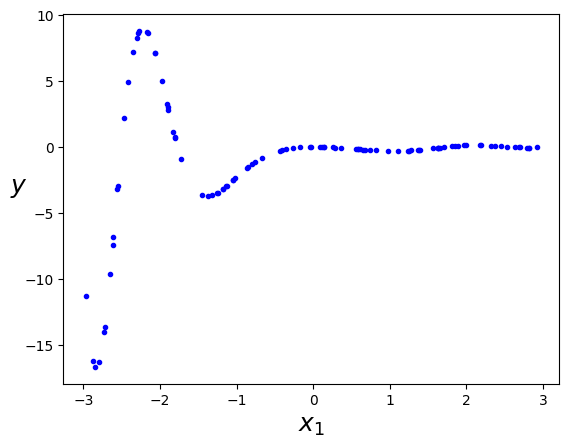

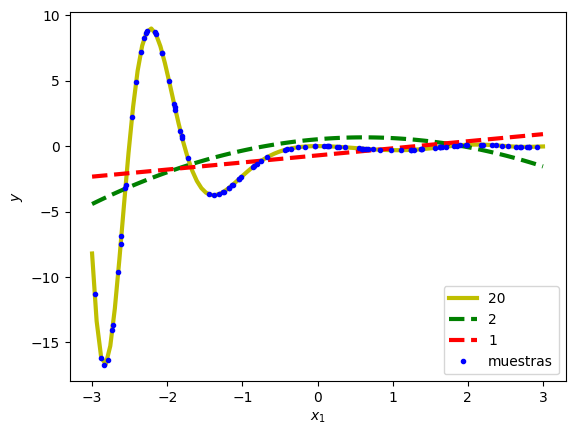

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
np.random.seed(42)
m = 100
X=np.random.uniform(-3,3,(m,1))
y =-(np.sin(X**2)) * np.exp(-X)
#y =np.exp(X)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
# plt.axis([-3, 3, -2, 20])
plt.show()

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)



lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# print(lin_reg.intercept_, lin_reg.coef_)
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)




for style, width, degree in (("y-", 3, 20), ("g--", 3, 2), ("r--", 3, 1)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([("poly_features", polybig_features), ("lin_reg", lin_reg),])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(X, y, "b.", linewidth=3,label="muestras")
plt.legend(loc="lower right")
plt.xlabel("$x_{1}$")
plt.ylabel("$y$")
#plt.axis([-3, 3, -500, 500])
plt.show()
